## Classification automatique des sommeil humain

### Analyse préliminaire : ALD

In [1]:
#Importation des bibliothèques nécessaires
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis 
import numpy as np

 

In [2]:
#Importation des 3 jeux de données (fichiers excel) sans prendre la colonne index
data1 = pd.read_excel("Sujet1.xlsx", index_col=0)
data2 = pd.read_excel("Sujet2.xlsx", index_col=0)
data3 = pd.read_excel("Sujet3.xlsx", index_col=0)
data1_artefacts = pd.read_excel("Sujet1_artefact.xlsx", index_col=0)

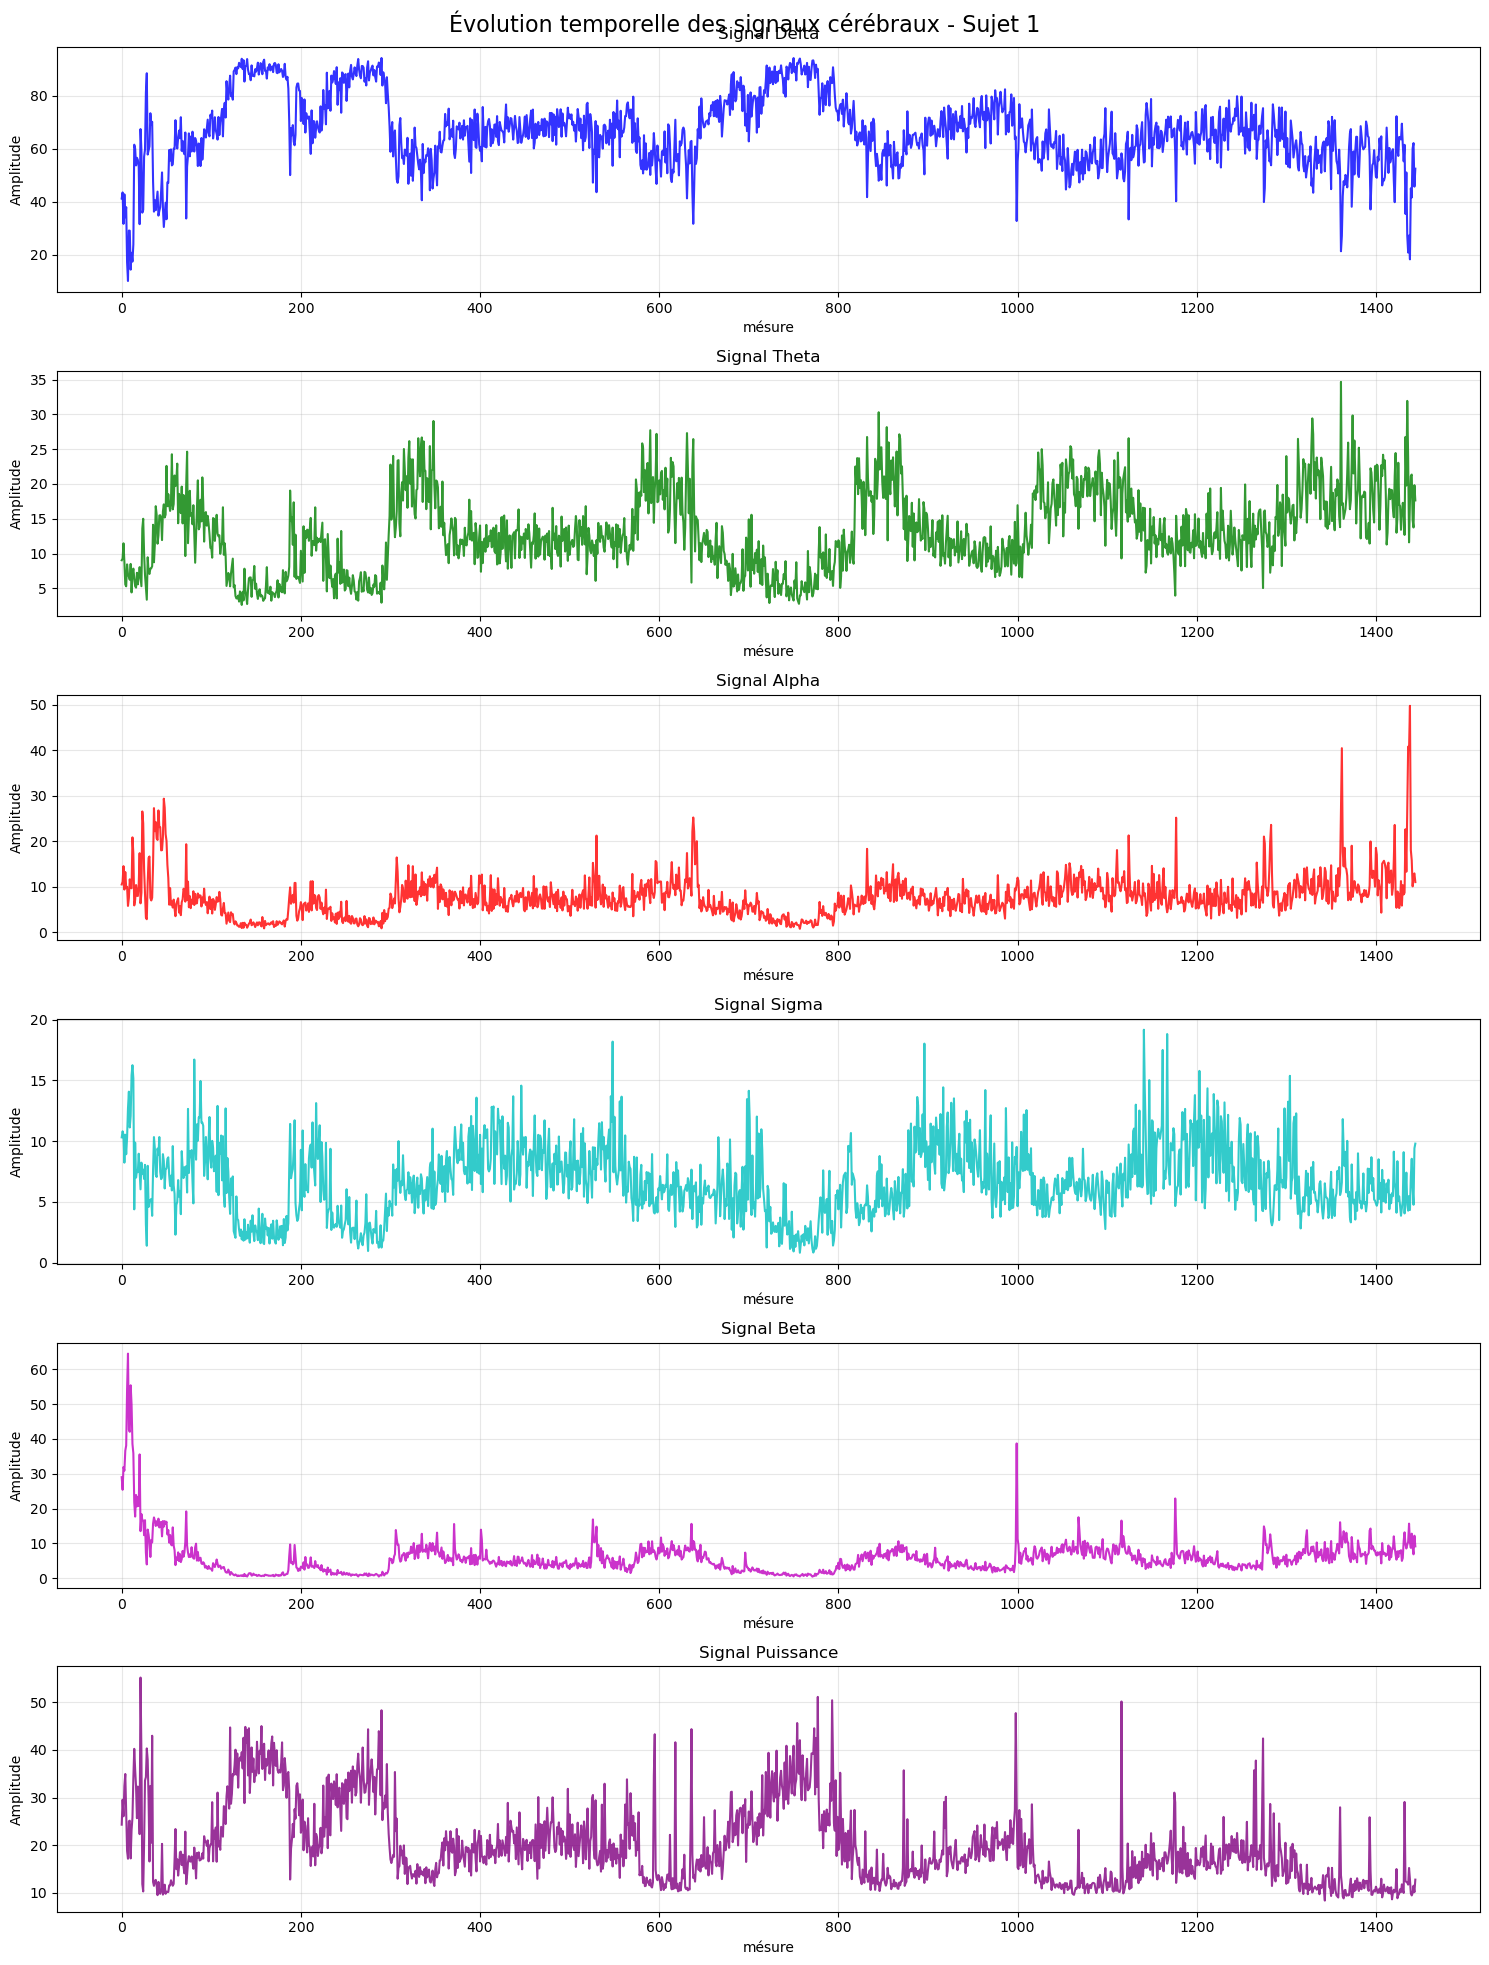

In [3]:

fig, axs = plt.subplots(6, 1, figsize=(15, 20))
fig.suptitle('Évolution temporelle des signaux cérébraux - Sujet 1', fontsize=16)


colores = ['b', 'g', 'r', 'c', 'm', 'purple']
ondas = ['delta', 'theta', 'alpha', 'sigma', 'beta', 'puissance']


for i, (onda, color) in enumerate(zip(ondas, colores)):
    axs[i].plot(data1.index, data1[onda], color=color, alpha=0.8)
    axs[i].set_title(f'Signal {onda.capitalize()}')
    axs[i].set_xlabel('mésure')
    axs[i].set_ylabel('Amplitude')
    axs[i].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()


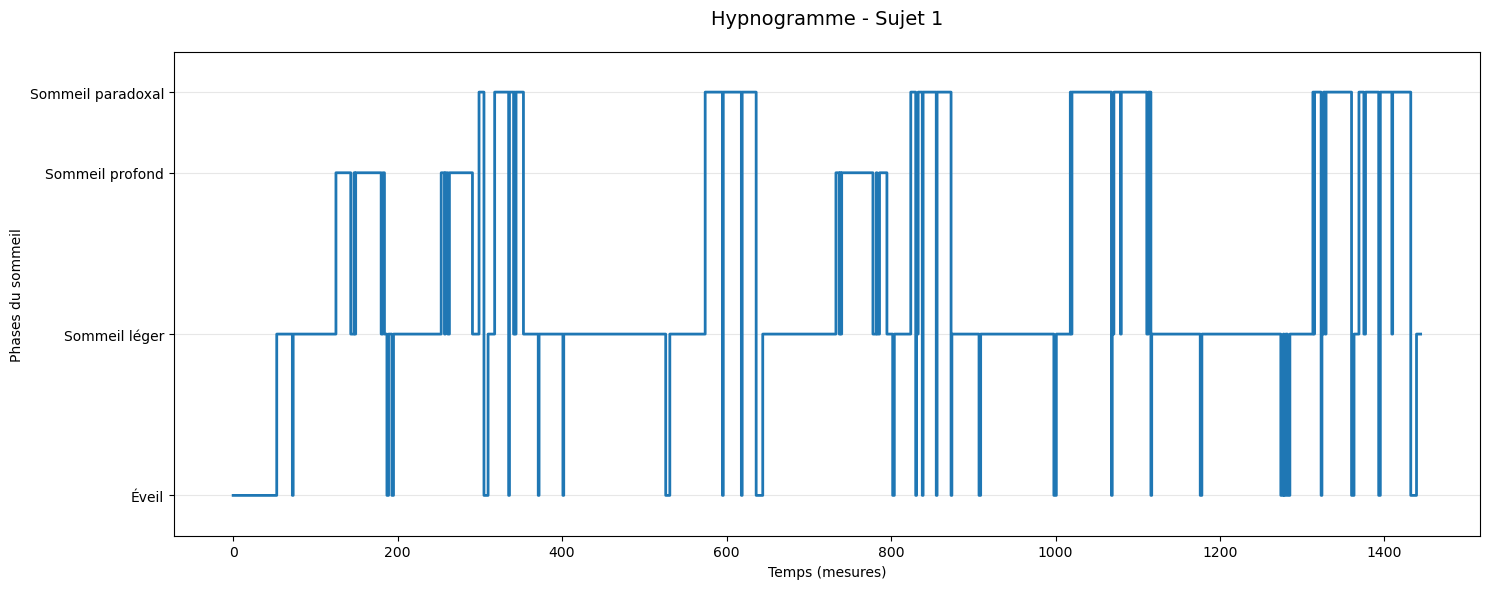


Temps passé dans chaque phase:
Éveil: 117 mesures (8.1%)
Sommeil léger: 855 mesures (59.2%)
Sommeil profond: 140 mesures (9.7%)
Sommeil paradoxal: 333 mesures (23.0%)


In [4]:
plt.figure(figsize=(15, 6))

fase_labels = {
    0: 'Éveil',
    2: 'Sommeil léger',
    4: 'Sommeil profond',
    5: 'Sommeil paradoxal'
}

plt.plot(data1.index, data1['phase'], drawstyle='steps-post', linewidth=2)


plt.yticks([0, 2, 4, 5], ['Éveil', 'Sommeil léger', 'Sommeil profond', 'Sommeil paradoxal'])

plt.title('Hypnogramme - Sujet 1', fontsize=14, pad=20)
plt.xlabel('Temps (mesures)')
plt.ylabel('Phases du sommeil')

plt.grid(True, axis='y', alpha=0.3)

plt.ylim(-0.5, 5.5)

plt.tight_layout()

plt.show()


tiempo_fases = data1['phase'].value_counts().sort_index()
print("\nTemps passé dans chaque phase:")
for fase, tiempo in tiempo_fases.items(): 
    if fase in fase_labels:
        porcentaje = (tiempo / len(data1)) * 100
        print(f"{fase_labels[fase]}: {tiempo} mesures ({porcentaje:.1f}%)")

In [5]:
#Analyse exploratoire des données
print(f"Sujet 1 :\n {data1.head()} \n {data1.describe()} \n {data1.info()} \n")
print(f"Sujet 2 :\n {data2.head()} \n {data2.describe()} \n {data2.info()} \n")
print(f"Sujet 3 :\n {data3.head()} \n {data3.describe()} \n {data3.info()} \n")

<class 'pandas.core.frame.DataFrame'>
Index: 1445 entries, 0 to 1444
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   delta      1445 non-null   float64
 1   theta      1445 non-null   float64
 2   alpha      1445 non-null   float64
 3   sigma      1445 non-null   float64
 4   beta       1445 non-null   float64
 5   puissance  1445 non-null   float64
 6   phase      1445 non-null   int64  
dtypes: float64(6), int64(1)
memory usage: 90.3 KB
Sujet 1 :
        delta      theta      alpha      sigma       beta  puissance  phase
0  41.175791   9.037395  10.451165  10.313667  29.021982  24.302703      0
1  43.470161   9.271601  11.042753  10.813209  25.402275  29.538265      0
2  31.621804  11.466909  14.473431  10.517110  31.920745  26.059694      0
3  42.769873   8.762487   9.329642   8.234078  30.903919  32.394789      0
4  34.107991   5.557928  13.180524  10.528618  36.624938  34.936519      0 
              delta       

In [6]:
data1["Group"] = data1["phase"].astype("category")
data2["Group"] = data2["phase"].astype("category")
data3["Group"] = data3["phase"].astype("category")
print("Distribution des classes dans le Sujet 1 :")
print(data1["Group"].value_counts())

Distribution des classes dans le Sujet 1 :
Group
2    855
5    333
4    140
0    117
Name: count, dtype: int64


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

def doALD(Xdf, group_col):
    """
    Réalise une Analyse Linéaire Discriminante (ALD / LDA) générique sur un DataFrame.
    
    Paramètres :
    ------------
    Xdf : pandas.DataFrame
        Le jeu de données à analyser.
    group_col : str
        Nom de la colonne contenant les groupes ou classes.
    """
    #On va créer une copy du dataframe sans la colonne beta

    Xdf = Xdf.drop(columns=['beta'])

    # === Vérifications de base ===
    if group_col not in Xdf.columns:
        raise KeyError(f"La colonne '{group_col}' est absente du DataFrame.")
    
    # Colonnes numériques (toutes sauf la colonne de groupe)
    numeric_cols = Xdf.select_dtypes(include=[np.number]).columns.tolist()
    if group_col in numeric_cols:
        numeric_cols.remove(group_col)

    X = Xdf[numeric_cols]
    y = Xdf[group_col]

    print(f"\nVariables numériques utilisées : {numeric_cols}")
    print(f"Nombre d'individus : {X.shape[0]}, nombre de variables : {X.shape[1]}")
    print(f"Classes trouvées : {np.unique(y)}\n")

    # === Boxplots par groupe ===
    plt.figure(figsize=(10, 6))
    Xdf.boxplot(column=numeric_cols, by=group_col)
    plt.title("Boxplots des variables par groupe")
    plt.suptitle("")  # Supprime le titre automatique ajouté par pandas
    plt.show()

    # === Moyenne par groupe ===
    G = Xdf.groupby(group_col)[numeric_cols].mean()
    print("Moyenne des variables par groupe :\n", G, "\n")

    # === Matrice de dispersion ===
    pd.plotting.scatter_matrix(X, figsize=(8, 8), c=pd.factorize(y)[0])
    plt.suptitle("Matrice de dispersion (colorée par groupe)")
    plt.show()

    # === Analyse Linéaire Discriminante ===
    lda = LinearDiscriminantAnalysis()
    coord_lda = lda.fit_transform(X, y)

    nb_axe_dis = len(np.unique(y)) - 1
    print("Nombre d’axes discriminants :", nb_axe_dis)

    # === Pouvoir discriminant ===
    plt.figure()
    plt.bar(np.arange(1, nb_axe_dis + 1), lda.explained_variance_ratio_)
    plt.ylabel("Pouvoir discriminant")
    plt.xlabel("Axes discriminants")
    plt.title("Variance expliquée par chaque axe")
    plt.show()

    # === Projection des individus ===
    plt.figure(figsize=(10, 8))
    if coord_lda.shape[1] == 1:
        # Cas où il n'y a qu'un seul axe discriminant
        plt.scatter(coord_lda[:, 0], np.zeros_like(coord_lda[:, 0]),
                    c=pd.factorize(y)[0], cmap="viridis")
        plt.xlabel("Axe discriminant 1")
        plt.title("Projection des individus (1 seul axe discriminant)")
    else:
        scatter = plt.scatter(coord_lda[:, 0], coord_lda[:, 1],
                              c=pd.factorize(y)[0], cmap="viridis")
        plt.xlabel("Axe discriminant 1")
        plt.ylabel("Axe discriminant 2")
        plt.title("Projection des individus dans l’espace discriminant")

        handles, _ = scatter.legend_elements()
        labels = [str(c) for c in np.unique(y)]
        plt.legend(handles=handles, labels=labels, title="Groupes")

    plt.show()

    # === Centres de gravité dans l’espace discriminant ===
# =======================
# Centres de gravité des classes
# =======================
    passage = lda.scalings_
    G_center = (G - X.mean()) @ passage
    G_center = G_center.to_numpy()  # conversion explicite

    plt.figure(figsize=(10, 8))
    plt.scatter(coord_lda[:, 0],
                coord_lda[:, 1] if coord_lda.shape[1] > 1 else np.zeros_like(coord_lda[:, 0]),
                c=pd.factorize(y)[0], cmap="viridis", alpha=0.5)

    if G_center.shape[1] >= 2:
        plt.scatter(G_center[:, 0], G_center[:, 1],
                    c="red", marker="x", s=100, label="Centres de classes")
        plt.xlabel("Axe discriminant 1")
        plt.ylabel("Axe discriminant 2")
    else:
        plt.scatter(G_center[:, 0], np.zeros_like(G_center[:, 0]),
                    c="red", marker="x", s=100, label="Centres de classes")
        plt.xlabel("Axe discriminant 1")

    plt.legend()
    plt.title("Centres de gravité des classes dans l’espace discriminant")
    plt.show()


    # === Cercle des corrélations ===
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    plt.axhline(0, color='grey', lw=1)
    plt.axvline(0, color='grey', lw=1)
    cercle = plt.Circle((0, 0), 1, color='blue', fill=False)
    ax.add_artist(cercle)

    for col in numeric_cols:
        if coord_lda.shape[1] > 1:
            x_corr = np.corrcoef(X[col], coord_lda[:, 0])[0, 1]
            y_corr = np.corrcoef(X[col], coord_lda[:, 1])[0, 1]
        else:
            x_corr = np.corrcoef(X[col], coord_lda[:, 0])[0, 1]
            y_corr = 0
        plt.annotate(col, (x_corr, y_corr))
        plt.quiver(0, 0, x_corr, y_corr, color="black", scale=2)

    plt.title("Cercle des corrélations")
    plt.show()



Variables numériques utilisées : ['delta', 'theta', 'alpha', 'sigma', 'puissance']
Nombre d'individus : 1445, nombre de variables : 5
Classes trouvées : [0 2 4 5]



<Figure size 1000x600 with 0 Axes>

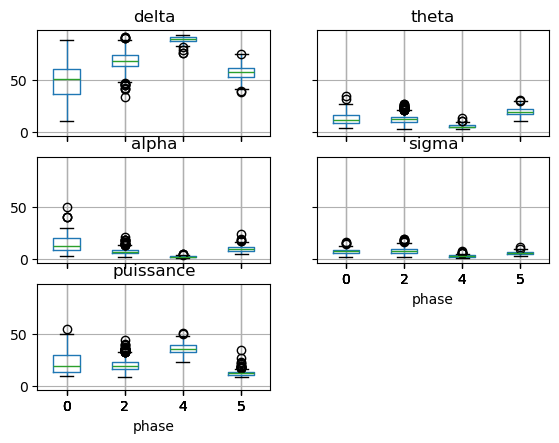

Moyenne des variables par groupe :
            delta      theta      alpha     sigma  puissance
phase                                                      
0      49.276641  12.394193  14.791953  7.231790  22.268954
2      68.907084  12.033435   6.849199  7.764595  19.918238
4      89.352842   5.151921   2.016542  2.526630  35.919785
5      57.734272  19.398136   9.672606  5.688848  12.366923 



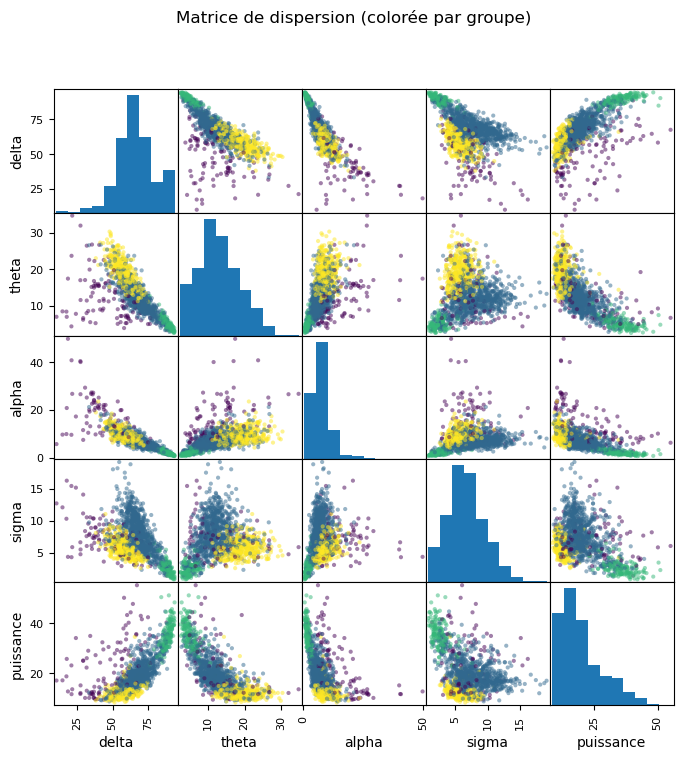

Nombre d’axes discriminants : 3


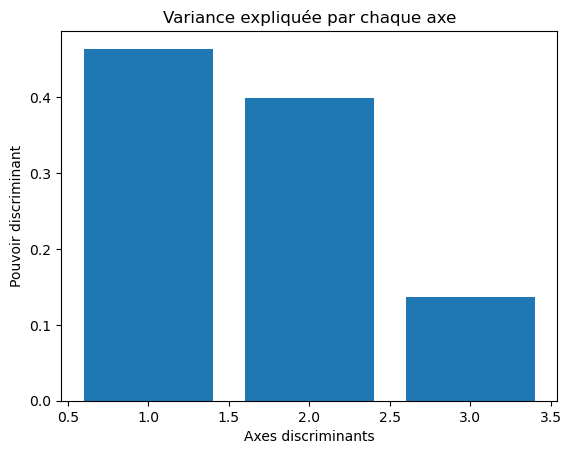

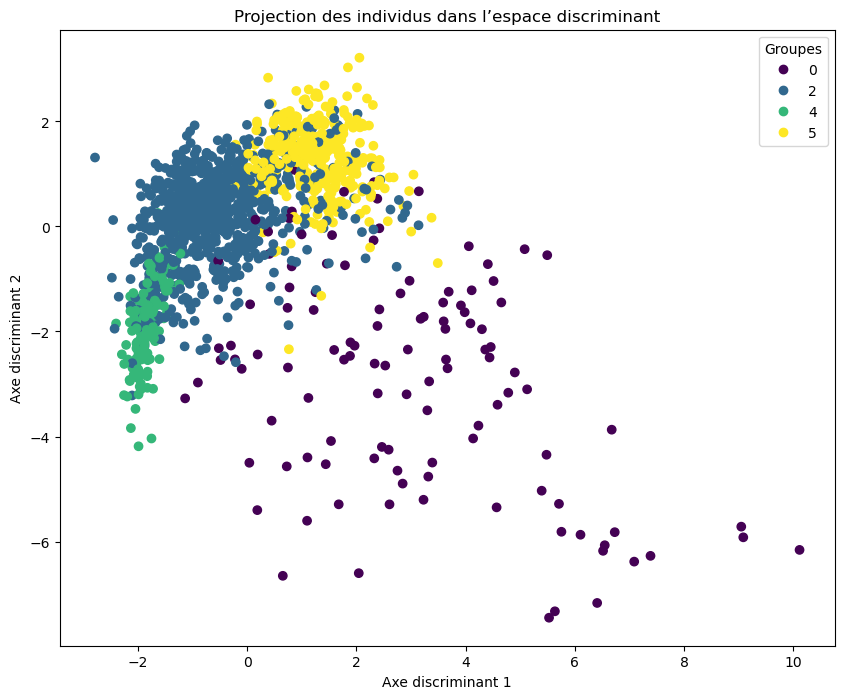

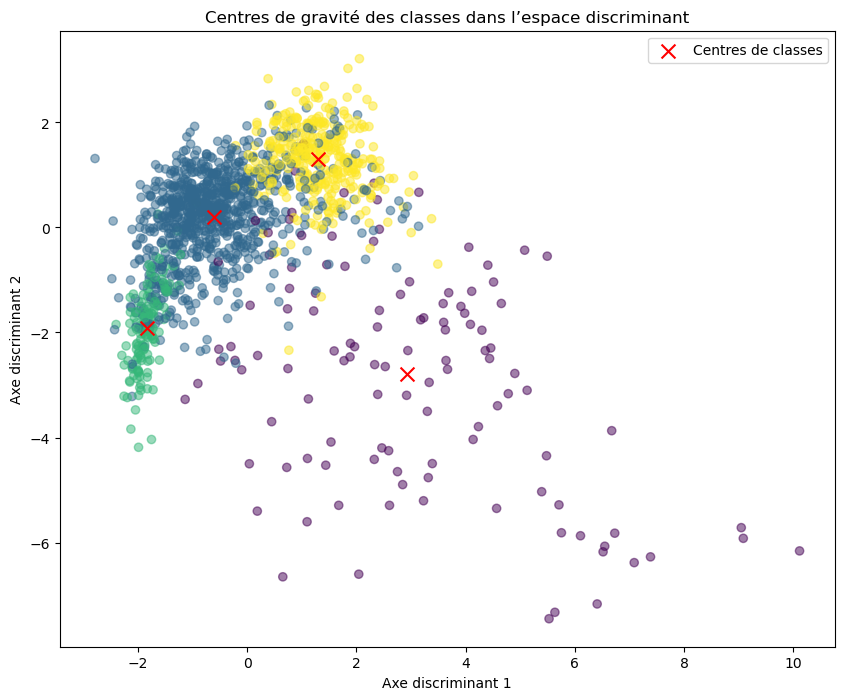

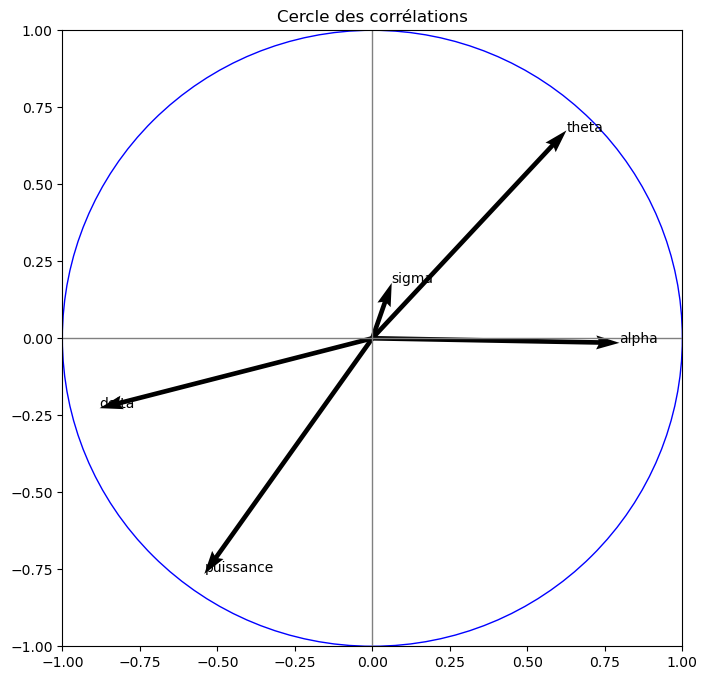

In [8]:
#On fait l'ALD pour chaque sujet.
doALD(data1,'phase')


## Construction des classifieurs

1. Classifieur Bayésien quadratique

In [9]:
#On va faire une fonction qui va faire un classifieur bayésien quadratique pour chaque sujet.

from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.naive_bayes import GaussianNB as GNB
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import confusion_matrix    



def bayesClassifier(Xdf, group_col,classifier,name = None):
    """
    Réalise un classifieur bayésien quadratique sur un DataFrame.
    
    Paramètres :
    ------------
    Xdf : pandas.DataFrame
        Le jeu de données à analyser.
    group_col : str
        Nom de la colonne contenant les groupes ou classes.
    """
    #On va créer une copy du dataframe sans la colonne beta

    Xdf = Xdf.drop(columns=['beta'])

    # === Vérifications de base ===
    if group_col not in Xdf.columns:
        raise KeyError(f"La colonne '{group_col}' est absente du DataFrame.")
    
    # Colonnes numériques (toutes sauf la colonne de groupe)
    numeric_cols = Xdf.select_dtypes(include=[np.number]).columns.tolist()
    if group_col in numeric_cols:
        numeric_cols.remove(group_col)

    X = Xdf[numeric_cols]
    y = Xdf[group_col]

    qda = classifier
    #On divise les données en train et test
    #On va prendre les 420 premières lignes pour le training et le reste pour le test
    X_train = X.iloc[:420, :]
    y_train = y.iloc[:420]
    X_test = X.iloc[420:, :]
    y_test = y.iloc[420:]
    qda.fit(X_train, y_train)
    y_pred = qda.predict(X_test)
    accuracy = np.mean(y_pred == y_test)
    print(f"Accuracy du classifieur {name or ""} : {accuracy*100:.2f}%")
    #Balance accuracy
    bal_accuracy = balanced_accuracy_score(y_test, y_pred)
    print(f"Balanced Accuracy du classifieur {name or ""} : {bal_accuracy*100:.2f}%\n")
    #à chaque fois on affiche la matrice de confusion avec une heatmap avec les valeurs
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    cm2 = confusion_matrix(y_test, y_pred)

    cm = cm*100
    plt.figure(figsize=(5, 5))  
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Matrice de confusion du classifieur {name or ""}')
    tick_marks = np.arange(len(np.unique(y)))
    plt.xticks(tick_marks, np.unique(y))
    plt.yticks(tick_marks, np.unique(y))
    plt.xlabel('Classe prédite')
    plt.ylabel('Classe réelle')
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, f"{cm[i, j]:.1f}% ({cm2[i, j]:.2f})",
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.show()


    

Sujet 1 :
Accuracy du classifieur Bayésien Quadratique : 83.32%
Balanced Accuracy du classifieur Bayésien Quadratique : 79.68%



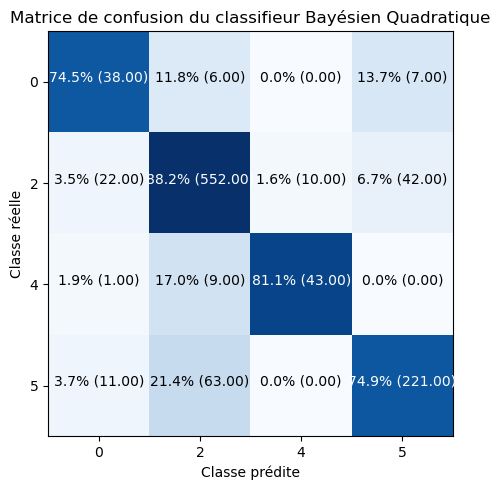

Accuracy du classifieur Bayésien Linéaire : 81.76%
Balanced Accuracy du classifieur Bayésien Linéaire : 75.66%



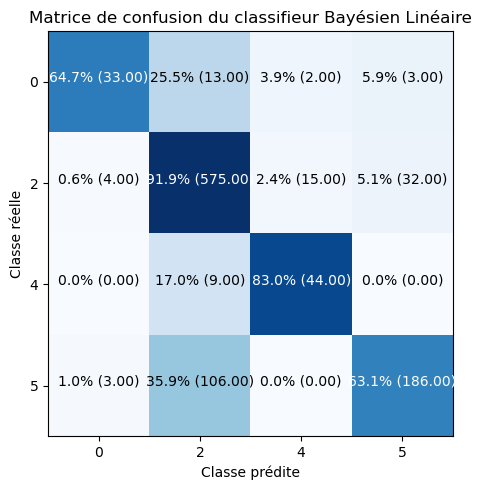

Accuracy du classifieur Naïve Bayésien : 80.98%
Balanced Accuracy du classifieur Naïve Bayésien : 75.28%



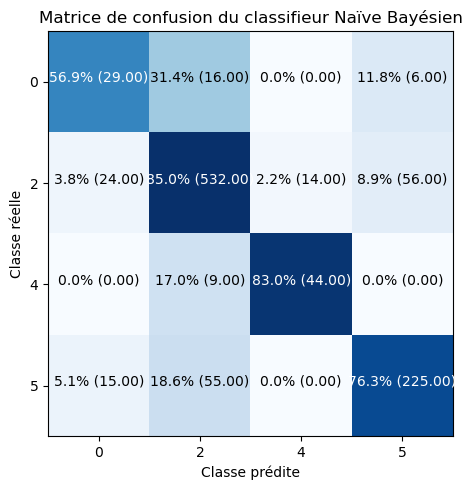


Sujet 2 :
Accuracy du classifieur Bayésien Quadratique : 87.73%
Balanced Accuracy du classifieur Bayésien Quadratique : 84.22%



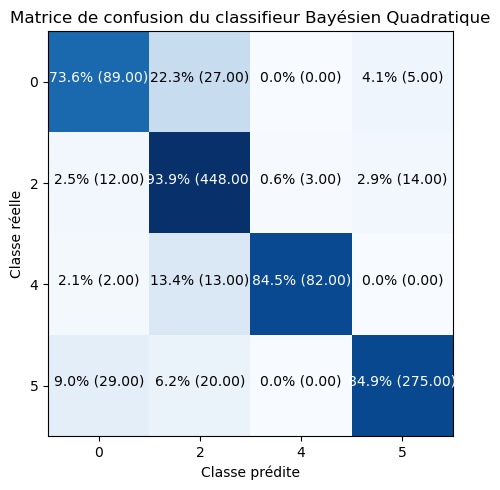

Accuracy du classifieur Bayésien Linéaire : 79.20%
Balanced Accuracy du classifieur Bayésien Linéaire : 76.84%



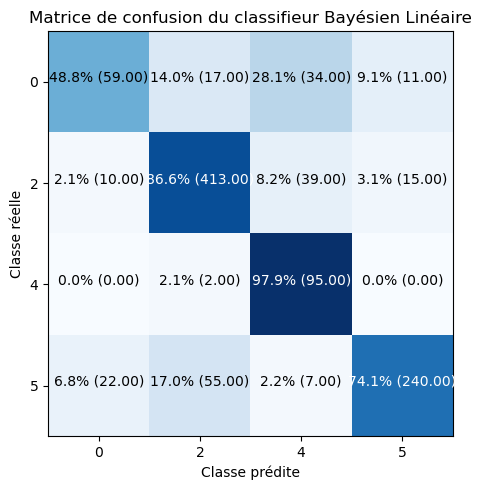

Accuracy du classifieur Naïve Bayésien : 70.95%
Balanced Accuracy du classifieur Naïve Bayésien : 67.59%



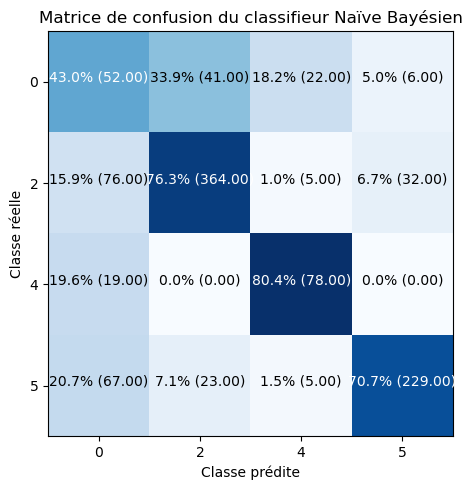


Sujet 3 :
Accuracy du classifieur Bayésien Quadratique : 82.43%
Balanced Accuracy du classifieur Bayésien Quadratique : 83.80%



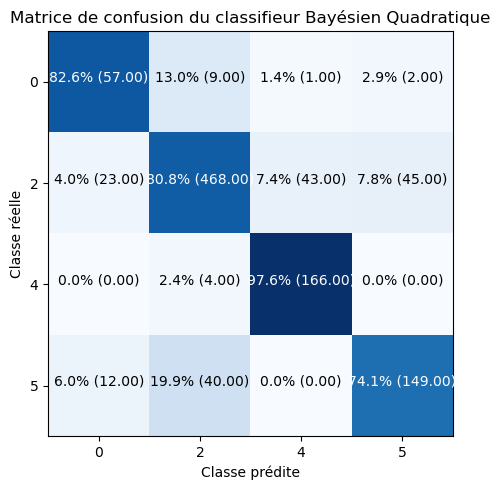

Accuracy du classifieur Bayésien Linéaire : 86.46%
Balanced Accuracy du classifieur Bayésien Linéaire : 85.16%



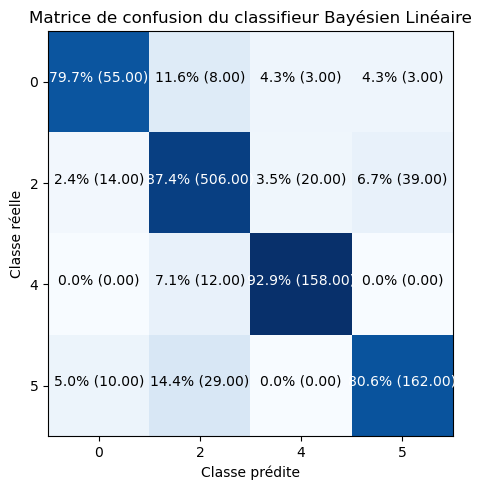

Accuracy du classifieur Naïve Bayésien : 76.74%
Balanced Accuracy du classifieur Naïve Bayésien : 72.82%



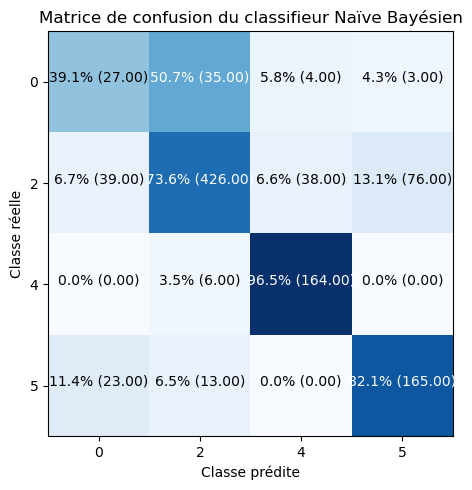

In [10]:
print("Sujet 1 :")
bayesClassifier(data1, 'phase', QDA(), name="Bayésien Quadratique")
bayesClassifier(data1, 'phase', LDA(), name="Bayésien Linéaire")
bayesClassifier(data1, 'phase', GNB(), name="Naïve Bayésien")
print("\nSujet 2 :")
bayesClassifier(data2, 'phase', QDA(), name="Bayésien Quadratique")
bayesClassifier(data2, 'phase', LDA(), name="Bayésien Linéaire")
bayesClassifier(data2, 'phase', GNB(), name="Naïve Bayésien")
print("\nSujet 3 :")    
bayesClassifier(data3, 'phase', QDA(), name="Bayésien Quadratique")
bayesClassifier(data3, 'phase', LDA(), name="Bayésien Linéaire")
bayesClassifier(data3, 'phase', GNB(), name="Naïve Bayésien")

In [11]:
#Maintenant nous allons faire un classifieur kNN pour chaque sujet.
from sklearn.neighbors import KNeighborsClassifier as kNN
from sklearn.model_selection import cross_val_score

def kNNClassifier(Xdf, group_col):
    """
    Réalise un classifieur kNN sur un DataFrame, fais vaier le nombre de voisins et valide le modèle 
    par validation croisée.
    
    Paramètres :
    ------------
    Xdf : pandas.DataFrame
        Le jeu de données à analyser.
    group_col : str
        Nom de la colonne contenant les groupes ou classes.
    n_neighbors : int
        Nombre de voisins à considérer.
    """

    #On va créer une copy du dataframe sans la colonne beta

    Xdf = Xdf.drop(columns=['beta'])
    #On va commnecer par centrer et réduire les données
    Xdf_numeric = Xdf.select_dtypes(include=[np.number])
    Xdf_numeric = (Xdf_numeric - Xdf_numeric.mean()) / Xdf_numeric.std()
    
    # === Vérifications de base ===
    if group_col not in Xdf.columns:
        raise KeyError(f"La colonne '{group_col}' est absente du DataFrame.")
    
    # Colonnes numériques (toutes sauf la colonne de groupe)
    numeric_cols = Xdf.select_dtypes(include=[np.number]).columns.tolist()
    if group_col in numeric_cols:
        numeric_cols.remove(group_col)

    X = Xdf[numeric_cols]
    y = Xdf[group_col]

    #On divise les données en train et test
    #On va prendre les 420 premières lignes pour le training et le reste pour le test
    X_train = X.iloc[:420, :]
    y_train = y.iloc[:420]
    X_test = X.iloc[420:, :]
    y_test = y.iloc[420:]

    #On va tester plusieurs valeurs de k
    k_values = range(1, 31)
    accuracies = []
    min_accuracies = []
    max_accuracies = []

    for k in k_values:
        knn = kNN(n_neighbors=k)
        #On va faire de la validation croisée
        cv_results = cross_val_score(knn, X_train, y_train, cv=5, scoring='balanced_accuracy')
        mean_accuracy = np.mean(cv_results)
        min_accuracy = np.min(cv_results)
        max_accuracy = np.max(cv_results)
        accuracies.append(mean_accuracy)
        min_accuracies.append(min_accuracy)
        max_accuracies.append(max_accuracy)


    #On affiche les résultats
    plt.figure(figsize=(10, 6))
    plt.plot(k_values, min_accuracies, marker='o', label='Min Accuracy')
    plt.plot(k_values, accuracies, marker='o', label='Mean Accuracy')
    plt.plot(k_values, max_accuracies, marker='o', label='Max Accuracy')
    plt.title("kNN Classifier: Accuracy vs Number of Neighbors")
    plt.xlabel("Number of Neighbors (k)")
    plt.ylabel("Balanced Accuracy")
    plt.legend()
    plt.xticks(k_values)
    plt.grid()
    plt.show()

def kNNTest(Xdf, group_col, k):
    """
    Teste un classifieur kNN sur un DataFrame avec un nombre de voisins donné.
    
    Paramètres :
    ------------
    Xdf : pandas.DataFrame
        Le jeu de données à analyser.
    group_col : str
        Nom de la colonne contenant les groupes ou classes.
    n_neighbors : int
        Nombre de voisins à considérer.
    """

    #On va créer une copy du dataframe sans la colonne beta

    Xdf = Xdf.drop(columns=['beta'])
    #On va commnecer par centrer et réduire les données
    Xdf_numeric = Xdf.select_dtypes(include=[np.number])
    Xdf_numeric = (Xdf_numeric - Xdf_numeric.mean()) / Xdf_numeric.std()
    
    # === Vérifications de base ===
    if group_col not in Xdf.columns:
        raise KeyError(f"La colonne '{group_col}' est absente du DataFrame.")
    
    # Colonnes numériques (toutes sauf la colonne de groupe)
    numeric_cols = Xdf.select_dtypes(include=[np.number]).columns.tolist()
    if group_col in numeric_cols:
        numeric_cols.remove(group_col)

    X = Xdf[numeric_cols]
    y = Xdf[group_col]

    #On divise les données en train et test
    #On va prendre les 420 premières lignes pour le training et le reste pour le test
    X_train = X.iloc[:420, :]
    y_train = y.iloc[:420]
    X_test = X.iloc[420:, :]
    y_test = y.iloc[420:]

    #On choisit k et on teste sur les données de test
    knn = kNN(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = np.mean(y_pred == y_test)
    print(f"Accuracy du classifieur kNN avec k={k} : {accuracy*100:.2f}%")
    bal_accuracy = balanced_accuracy_score(y_test, y_pred)


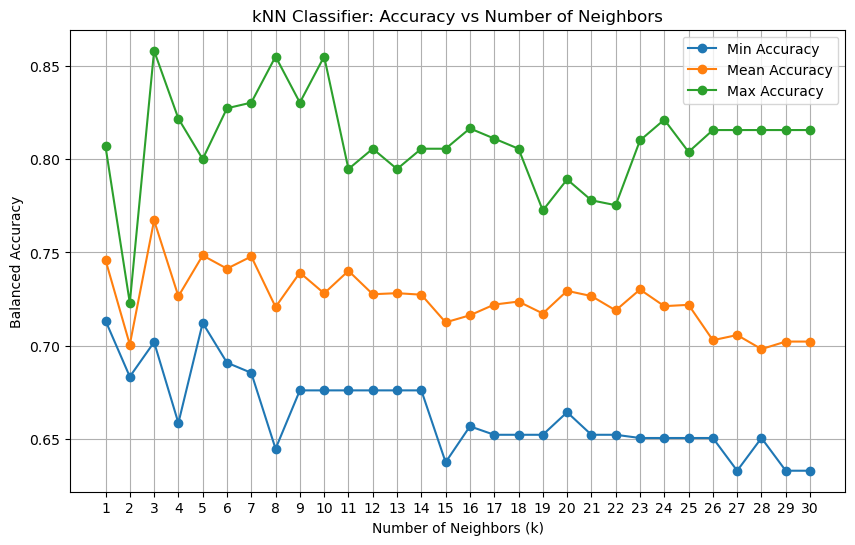

In [12]:
kNNClassifier(data1, 'phase')


In [13]:
#On va choisir k = 3 et tester le classifieur kNN
kNNTest(data1, 'phase', 3)

Accuracy du classifieur kNN avec k=3 : 80.20%


### Classsifieur quadratique en prenant compte du rejet d'ambiguïté


In [14]:
#Définition de la fonction qui va faire un classifieur quadratique avec rejet d'ambiguïté
def bayesClassifierWithRejection(Xdf, group_col, cr=0 ):
    """
    Réalise un classifieur bayésien quadratique avec rejet d'ambiguïté sur un DataFrame.
    
    Paramètres :
    ------------
    Xdf : pandas.DataFrame
        Le jeu de données à analyser.
    group_col : str
        Nom de la colonne contenant les groupes ou classes.
    cr : float
        Seuil de rejet pour l'ambiguïté (entre 1/M et 1).
    """
    #On va créer une copy du dataframe sans la colonne beta

    Xdf = Xdf.drop(columns=['beta'])

    # === Vérifications de base ===
    if group_col not in Xdf.columns:
        raise KeyError(f"La colonne '{group_col}' est absente du DataFrame.")
    
    # Colonnes numériques (toutes sauf la colonne de groupe)
    numeric_cols = Xdf.select_dtypes(include=[np.number]).columns.tolist()
    if group_col in numeric_cols:
        numeric_cols.remove(group_col)

    X = Xdf[numeric_cols]
    y = Xdf[group_col]

    #On divise les données en train et test
    #On va prendre les 420 premières lignes pour le training et le reste pour le test
    X_train = X.iloc[:420, :]
    y_train = y.iloc[:420]
    X_test = X.iloc[420:, :]
    y_test = y.iloc[420:]

    qda = QDA()
    qda.fit(X_train, y_train)
    y_proba = qda.predict_proba(X_test)
    y_pred = qda.predict(X_test)
    y_pred_without_rejection = y_pred.copy()
    #on va mettre la classe de rejet 'ambiguous' pour les probabilités inférieures au seuil cr
    
    for i in range(len(y_proba)):
        proba = np.max(qda.predict_proba(X_test.iloc[i:i+1, :]))
        if proba < cr:
            y_pred[i] = 1  #Classe de rejet 'ambiguous'

    match_classes_to_indexes = {0:0, 2:1, 4:2, 5:3, 1:-1} 

    #Matrice de confusion
    cm = np.zeros((len(np.unique(y)), len(np.unique(y))+1))
    for i in range(len(y_test)):
        true_class = y_test.iloc[i]
        pred_class = y_pred[i]

        pred_index = match_classes_to_indexes[int(pred_class)]
        true_index = match_classes_to_indexes[int(true_class)]
        cm[true_index, pred_index] += 1
    #On affiche la matrice de confusion avec une heatmap avec les valeurs
    plt.figure(figsize=(4, 4))
    
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Matrice de confusion du classifieur Quadratique avec rejet d\'ambiguïté')
    tick_marks = np.arange(len(np.unique(y))+1)
    plt.xticks(tick_marks, list(np.unique(y)) + ['ambiguous'])
    plt.yticks(tick_marks[:-1], np.unique(y))
    plt.xlabel('Classe prédite')
    plt.ylabel('Classe réelle')
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(int(cm[i, j]), 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.show()
    #On calcule la balanced accuracy en ignorant la classe de rejet
    y_test_filtered = y_test[y_pred != 1]   
    y_pred_filtered = y_pred[y_pred != 1]
    bal_accuracy = balanced_accuracy_score(y_test_filtered, y_pred_filtered)
    print(f"Balanced Accuracy du classifieur Quadratique avec rejet d'ambiguïté (cr={cr}): {bal_accuracy*100:.2f}%")
    print(f"Nombre d'échantillons rejetés : {np.sum(y_pred == 1)} sur {len(y_pred)} soit  {round(100.00*(np.sum(y_pred == 1))/len(y_pred)),2} %")
    print(f"Nombre d'échantillons bien classsifiés avant mais rejetés : {np.sum((y_test == y_pred_without_rejection) & (y_pred == 1))} sur {np.sum(y_pred==1)} soit  {round(100.00*(np.sum((y_test == y_pred_without_rejection) & (y_pred == 1)))/len(y_pred==1),2)} % des échantillons rejetés étaient  bien classés . \n")


Sujet 1 avec seuil de rejet 0.3:


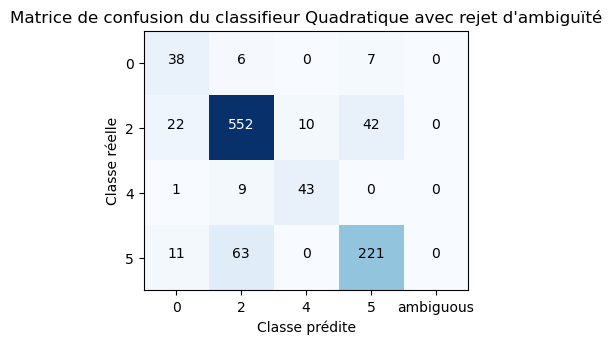

Balanced Accuracy du classifieur Quadratique avec rejet d'ambiguïté (cr=0.3): 79.68%
Nombre d'échantillons rejetés : 0 sur 1025 soit  (0, 2) %
Nombre d'échantillons bien classsifiés avant mais rejetés : 0 sur 0 soit  0.0 % des échantillons rejetés étaient  bien classés . 

Sujet 1 avec seuil de rejet 0.4:


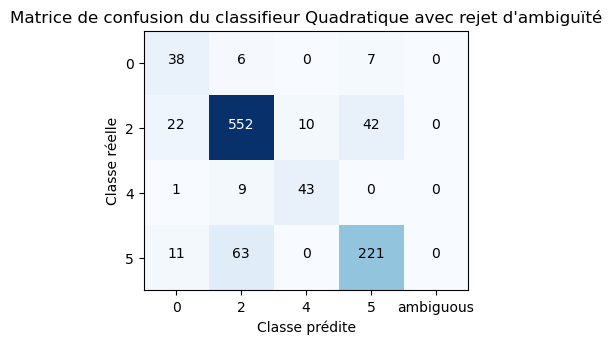

Balanced Accuracy du classifieur Quadratique avec rejet d'ambiguïté (cr=0.4): 79.68%
Nombre d'échantillons rejetés : 0 sur 1025 soit  (0, 2) %
Nombre d'échantillons bien classsifiés avant mais rejetés : 0 sur 0 soit  0.0 % des échantillons rejetés étaient  bien classés . 

Sujet 1 avec seuil de rejet 0.5:


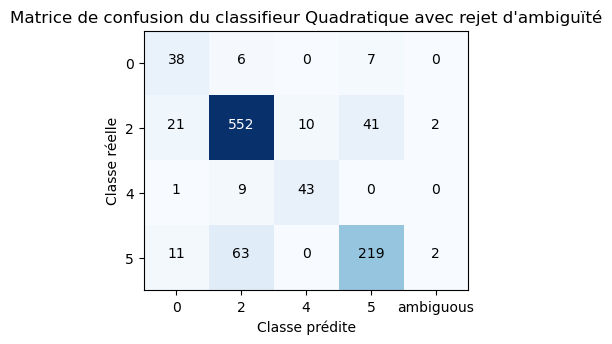

Balanced Accuracy du classifieur Quadratique avec rejet d'ambiguïté (cr=0.5): 79.71%
Nombre d'échantillons rejetés : 4 sur 1025 soit  (0, 2) %
Nombre d'échantillons bien classsifiés avant mais rejetés : 2 sur 4 soit  0.2 % des échantillons rejetés étaient  bien classés . 

Sujet 1 avec seuil de rejet 0.6:


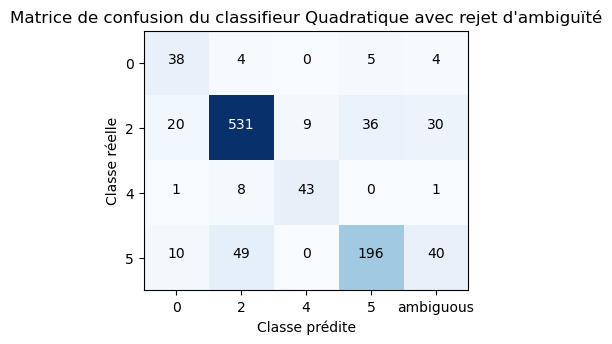

Balanced Accuracy du classifieur Quadratique avec rejet d'ambiguïté (cr=0.6): 82.38%
Nombre d'échantillons rejetés : 75 sur 1025 soit  (7, 2) %
Nombre d'échantillons bien classsifiés avant mais rejetés : 46 sur 75 soit  4.49 % des échantillons rejetés étaient  bien classés . 

Sujet 1 avec seuil de rejet 0.7:


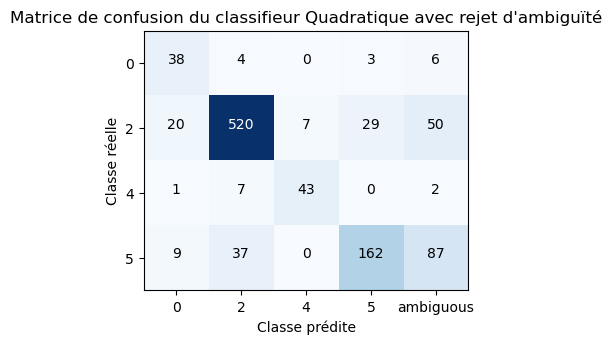

Balanced Accuracy du classifieur Quadratique avec rejet d'ambiguïté (cr=0.7): 84.23%
Nombre d'échantillons rejetés : 145 sur 1025 soit  (14, 2) %
Nombre d'échantillons bien classsifiés avant mais rejetés : 91 sur 145 soit  8.88 % des échantillons rejetés étaient  bien classés . 

Sujet 1 avec seuil de rejet 0.8:


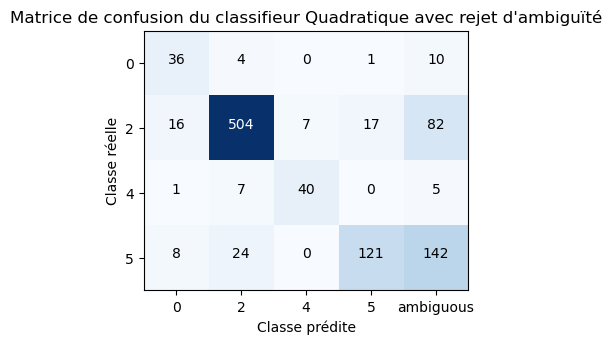

Balanced Accuracy du classifieur Quadratique avec rejet d'ambiguïté (cr=0.8): 85.72%
Nombre d'échantillons rejetés : 239 sur 1025 soit  (23, 2) %
Nombre d'échantillons bien classsifiés avant mais rejetés : 153 sur 239 soit  14.93 % des échantillons rejetés étaient  bien classés . 

Sujet 1 avec seuil de rejet 0.9:


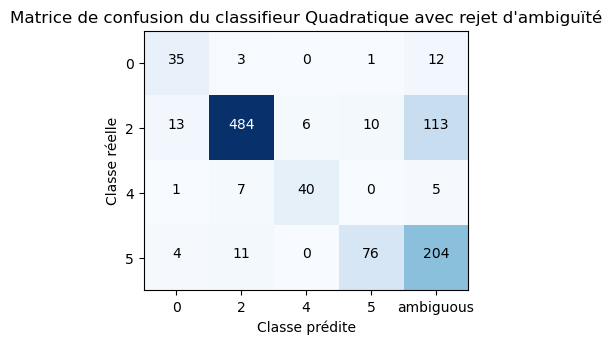

Balanced Accuracy du classifieur Quadratique avec rejet d'ambiguïté (cr=0.9): 87.74%
Nombre d'échantillons rejetés : 334 sur 1025 soit  (33, 2) %
Nombre d'échantillons bien classsifiés avant mais rejetés : 219 sur 334 soit  21.37 % des échantillons rejetés étaient  bien classés . 



In [15]:
for cr in [0.3, 0.4, 0.5,0.6, 0.7,0.8,0.9]:
    print(f"Sujet 1 avec seuil de rejet {cr}:")
    bayesClassifierWithRejection(data1, 'phase', cr)
    

Je choisis comme rejet en distance cr = 0.6 car il améliore notre balanced accuracy de 79.68% à 82.38% et seuleument 5% des rejets du modèle étaient bien classés sans rejet.
De plus si on augmente la valeur de  cr à 0.7 ce taux passe à 10% et le balanced accuracy n'est pas suffisament amélioré, il ne passe que de 82.38% à 84.23%.

In [16]:
#Implémentation du rejet en distance
def densite_proba(X_data,mean,cov):
    d = X_data.shape[0]
    det_cov = np.linalg.det(cov)
    norm_const = 1.0/ ( np.power((2*np.pi),float(d)/2) * np.power(det_cov,0.5) )
    X_mean = X_data - mean
    inv_cov = np.linalg.inv(cov)
    return norm_const * np.exp(-0.5 * np.transpose(X_mean)@inv_cov@X_mean)

#Définition de la fonction qui va faire un classifieur quadratique avec rejet d'ambiguïté
def bayesClassifierWithDistanceRejection(Xdf, group_col,percentile):
    """
    Réalise un classifieur bayésien quadratique avec rejet en distance sur un DataFrame.
    
    Paramètres :
    ------------
    Xdf : pandas.DataFrame
        Le jeu de données à analyser.
    group_col : str
        Nom de la colonne contenant les groupes ou classes.
    percentile : int
        Percentile pour déterminer le seuil de rejet en distance.

    """
    
    print(f"--- Classifieur Bayésien Quadratique avec rejet en distance au percentile {percentile} ---\n")
    #On va créer une copy du dataframe sans la colonne beta

    Xdf = Xdf.drop(columns=['beta'])
    # === Vérifications de base ===
    if group_col not in Xdf.columns:
        raise KeyError(f"La colonne '{group_col}' est absente du DataFrame.")
    
    # Colonnes numériques (toutes sauf la colonne de groupe)
    numeric_cols = Xdf.select_dtypes(include=[np.number]).columns.tolist()
    if group_col in numeric_cols:
        numeric_cols.remove(group_col)

    X = Xdf[numeric_cols]
    y = Xdf[group_col]


    #On divise les données en train et test
    #On va prendre les 420 premières lignes pour le training et le reste pour le test
    X_train = X.iloc[:420, :]
    y_train = y.iloc[:420]

    X_test = X.iloc[420:, :]
    y_test = y.iloc[420:]


  #On va enlever les artefacts des données d'entrainement
    X_train = X_train[y_train != -1]
    y_train = y_train[y_train != -1]


    #On va calculer les ddp
    #On va commnencer par calculer les centres des classes
    class_centers = []
    class_cov = []
    for classe in np.unique(y_train):
        class_data = X_train[y_train == classe]
        class_center = class_data.mean().to_numpy()
        class_centers.append(class_center)
        class_cov.append(np.cov(class_data, rowvar=False))
        
    #On calcule les densités de probabilité pour chaque échantillon
    ddp_by_class = np.zeros((X_train.shape[0], len(np.unique(y_train))))
    for i in range(X_train.shape[0]):
        for j, classe in enumerate(np.unique(y_train)):
            ddp_by_class[i, j] = densite_proba(X_train.iloc[i, :].to_numpy(), class_centers[j], class_cov[j])

    ddp = np.zeros(X_train.shape[0])

    for i in range(X_train.shape[0]):
        ddp[i] = np.sum(ddp_by_class[i, :])

    #On va apprendre une valeur de ddp seuil
    cd = np.percentile(ddp,percentile)
    print(f"Valeur de ddp seuil apprise : {cd} \n")

    match_classes_to_indexes = {}
    match_indexes_to_classes = {}
    for classe in np.unique(y_train):
        match_classes_to_indexes[int(classe)] = len(match_classes_to_indexes)
        match_indexes_to_classes[len(match_indexes_to_classes)] = int(classe)
    match_classes_to_indexes[-1] = 4
    match_indexes_to_classes[4] = -1

    #On va maintenant tester sur les données de test
    ddp_by_class_test = np.zeros((X_test.shape[0], len(np.unique(y_train))))
    for i in range(X_test.shape[0]):
        for j, classe in enumerate(np.unique(y_train)):
            ddp_by_class_test[i, j] = densite_proba(X_test.iloc[i, :].to_numpy(), class_centers[j], class_cov[j])

    ddp_test = np.zeros(X_test.shape[0])

    for i in range(X_test.shape[0]):
        ddp_test[i] = np.sum(ddp_by_class_test[i, :])   

    y_pred = np.zeros(X_test.shape[0])
    

    #On va chercher la valeur max de ddp pour les artefacts
    for i in range(X_test.shape[0]):
        if ddp_test[i] <= cd:
            y_pred[i] = -1  #Classe de rejet 'distance'

        else:
            #On prend la classe avec la plus grande ddp
            y_pred[i] = match_indexes_to_classes[np.argmax(ddp_by_class_test[i, :])]

    
    #On affiche la matrice de confusion
    cm = np.zeros((len(np.unique(y_test)), len(np.unique(y_test))))
    for i in range(len(y_test)):
        true_class = y_test.iloc[i]
        pred_class = y_pred[i]

        pred_index = match_classes_to_indexes[int(pred_class)]
        true_index = match_classes_to_indexes[int(true_class)]
        cm[true_index, pred_index] += 1
    #On affiche la matrice de confusion avec une heatmap avec les valeurs
    plt.figure(figsize=(4, 4))
    
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Matrice de confusion du classifieur Quadratique avec rejet en distance')
    labels = ['0', '2', '4', '5', 'Rejet (-1)']

    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels)
    plt.yticks(tick_marks, labels)
    plt.xlabel('Classe prédite')
    plt.ylabel('Classe réelle')
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(int(cm[i, j]), 'd'),
                horizontalalignment="center",
                color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.show()
    #On calcule le nombre de non artefacts bien classifiés avant rejet mais rejetés
    y_test_filtered = y_test[y_pred != -1]   
    y_pred_filtered = y_pred[y_pred != -1]
    bal_accuracy = balanced_accuracy_score(y_test_filtered, y_pred_filtered)
    print(f"Pourcentage d'artefacts dans les échantillons rejetés : {round(100.00*(np.sum((y_test == -1 ) & (y_pred == -1)))/np.sum(y_test==-1),2)} % \n")
    print(f"Balanced Accuracy du classifieur Quadratique avec rejet en distance (percentile={percentile}): {bal_accuracy*100:.2f}%")
    print(f"Nombre d'échantillons rejetés : {np.sum(y_pred == -1)} sur {len(y_pred)} soit  {round(100.00*(np.sum(y_pred == -1))/len(y_pred)),2} %")
    print(f"Nombre d'échantillons bien classifiés avant mais rejetés : {np.sum((y_test != -1 ) & (y_pred == -1))} sur {np.sum(y_pred==-1)} soit  {round(100.00*(np.sum((y_test != -1 ) & (y_pred == -1)))/np.sum(y_pred==-1),2)} % u nombre d'échantillons rejetés ne sont pas des artefacts . \n")
    print(f"{round(100.00*(np.sum((y_test != -1 ) & (y_pred == -1)))/len(y_pred),2)} % du nombre total d'échantillons sont bons et sont rejetés. \n")

--- Classifieur Bayésien Quadratique avec rejet en distance au percentile 10 ---

Valeur de ddp seuil apprise : 2.2195400601573484e-06 



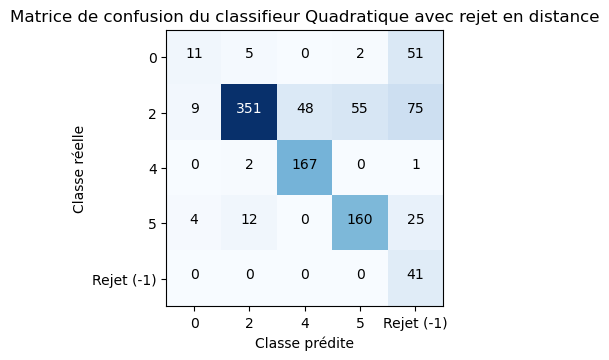

Pourcentage d'artefacts dans les échantillons rejetés : 100.0 % 

Balanced Accuracy du classifieur Quadratique avec rejet en distance (percentile=10): 81.66%
Nombre d'échantillons rejetés : 193 sur 1019 soit  (19, 2) %
Nombre d'échantillons bien classifiés avant mais rejetés : 152 sur 193 soit  78.76 % u nombre d'échantillons rejetés ne sont pas des artefacts . 

14.92 % du nombre total d'échantillons sont bons et sont rejetés. 

--- Classifieur Bayésien Quadratique avec rejet en distance au percentile 1 ---

Valeur de ddp seuil apprise : 4.409794474771259e-08 



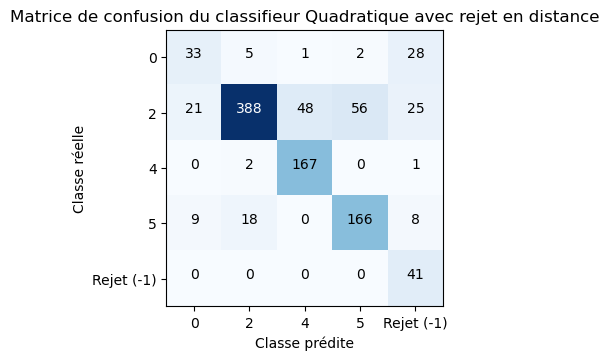

Pourcentage d'artefacts dans les échantillons rejetés : 100.0 % 

Balanced Accuracy du classifieur Quadratique avec rejet en distance (percentile=1): 85.24%
Nombre d'échantillons rejetés : 103 sur 1019 soit  (10, 2) %
Nombre d'échantillons bien classifiés avant mais rejetés : 62 sur 103 soit  60.19 % u nombre d'échantillons rejetés ne sont pas des artefacts . 

6.08 % du nombre total d'échantillons sont bons et sont rejetés. 



In [17]:
bayesClassifierWithDistanceRejection(data1_artefacts, 'phase',10)
bayesClassifierWithDistanceRejection(data1_artefacts, 'phase',1)



On peut voir que en acceptant de perdre 1% des bons echantillons on arrive à bien rejeter tous les artefacts

--- Classifieur Bayésien Quadratique avec rejet en distance au percentile 5 ---

Valeur de ddp seuil apprise : 3.9496750033973235e-07 



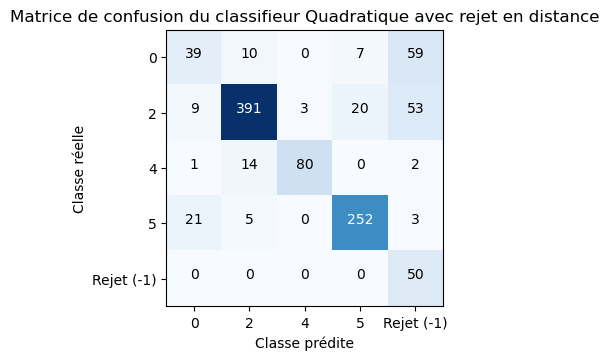

Pourcentage d'artefacts dans les échantillons rejetés : 100.0 % 

Balanced Accuracy du classifieur Quadratique avec rejet en distance (percentile=5): 84.23%
Nombre d'échantillons rejetés : 167 sur 1019 soit  (16, 2) %
Nombre d'échantillons bien classifiés avant mais rejetés : 117 sur 167 soit  70.06 % u nombre d'échantillons rejetés ne sont pas des artefacts . 

11.48 % du nombre total d'échantillons sont bons et sont rejetés. 



In [18]:
#Validation avec sujet2_artefacts.xlsx
bayesClassifierWithDistanceRejection(pd.read_excel("Sujet2_artefact.xlsx", index_col=0), 'phase',5)

## Inter sujets

In [19]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import balanced_accuracy_score, make_scorer
#On commence par concatener les ttrois jeux de données sans les artefacts

#Importation des 3 jeux de données (fichiers excel) sans prendre la colonne index
data1 = pd.read_excel("Sujet1.xlsx", index_col=0)
data2 = pd.read_excel("Sujet2.xlsx", index_col=0)
data3 = pd.read_excel("Sujet3.xlsx", index_col=0)

data_all = pd.concat([data1, data2, data3], ignore_index=True)


#On va créer les variables X et y


data_all = data_all.drop(columns=['beta'])

# Colonnes numériques (toutes sauf la colonne de groupe)
numeric_cols = data_all.select_dtypes(include=[np.number]).columns.tolist()

if "phase" in numeric_cols:
    numeric_cols.remove("phase")

X_all = data_all[numeric_cols]
y_all = data_all["phase"]

#On va ajouter une colonne pour determiner le sujet
groupes = np.concatenate([
    np.ones(len(data1)) * 1,  
    np.ones(len(data2)) * 2,  
    np.ones(len(data3)) * 3   
])

# Préparez les modèles
qda = QDA()
lda = LDA()
knn = kNN(n_neighbors=3) # 'k' que vous avez réglé avant
gnb = GNB()

models = {'QDA': qda, 'LDA': lda, 'KNN': knn, 'Gaussien_naïf': gnb}

# Préparez le validateur et le score
logo = LeaveOneGroupOut()
balanced_scorer = make_scorer(balanced_accuracy_score)

print("--- Scores de performance INTER-SUJET ---")

for name, model in models.items():
    # cross_val_score va faire les 3 tours (logo) pour vous
    scores = cross_val_score(model, X_all, y_all, 
                             cv=logo, 
                             groups=groupes, 
                             scoring=balanced_scorer)

    print(f"Balance-accuracy {name}: {np.mean(scores)*100:.2f}% (Ecart-type: {np.std(scores)*100:.2f}) min={np.min(scores)*100:.2f} max={np.max(scores)*100:.2f}")



--- Scores de performance INTER-SUJET ---
Balance-accuracy QDA: 64.39% (Ecart-type: 10.18) min=50.94 max=75.55
Balance-accuracy LDA: 67.85% (Ecart-type: 5.70) min=60.27 max=74.00
Balance-accuracy KNN: 64.17% (Ecart-type: 1.22) min=62.48 max=65.31
Balance-accuracy Gaussien_naïf: 62.13% (Ecart-type: 3.93) min=56.70 max=65.87
